# Netflix Movies & TV Shows

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [2]:
# Load Dataset
df = pd.read_csv("netflix_movies_and_tv_merged.csv")

In [3]:
# Basic EDA

print("Shape of Dataset:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape of Dataset: (32000, 19)

First 5 Rows:
   show_id   type                                         title  \
0    10192  Movie                           Shrek Forever After   
1    27205  Movie                                     Inception   
2    12444  Movie  Harry Potter and the Deathly Hallows: Part 1   
3    38757  Movie                                       Tangled   
4    10191  Movie                      How to Train Your Dragon   

                      director  \
0                Mike Mitchell   
1            Christopher Nolan   
2                  David Yates   
3   Byron Howard, Nathan Greno   
4  Chris Sanders, Dean DeBlois   

                                                cast  \
0  Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...   
1  Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...   
2  Daniel Radcliffe, Emma Watson, Rupert Grint, T...   
3  Mandy Moore, Zachary Levi, Donna Murphy, Ron P...   
4  Jay Baruchel, Gerard Butler, Craig Ferguson, A...   

          

In [4]:
print("\nData Information:")
print(df.info())


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  object 
 2   title         32000 non-null  object 
 3   director      20903 non-null  object 
 4   cast          30639 non-null  object 
 5   country       29737 non-null  object 
 6   date_added    32000 non-null  object 
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  object 
 11  language      32000 non-null  object 
 12  description   28662 non-null  object 
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
 18  content

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
show_id             0
type                0
title               0
director        11097
cast             1361
country          2263
date_added          0
release_year        0
rating              0
duration        16000
genres           1081
language            0
description      3338
popularity          0
vote_count          0
vote_average        0
budget          16000
revenue         16000
content_type        0
dtype: int64


In [6]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
            show_id  release_year        rating    popularity    vote_count  \
count  3.200000e+04  32000.000000  32000.000000  32000.000000  32000.000000   
mean   3.266129e+05   2017.500000      5.686738     42.617856    412.835219   
std    3.389191e+05      4.609844      2.635722    112.080448   1562.553446   
min    1.890000e+02   2010.000000      0.000000      2.323000      0.000000   
25%    8.212950e+04   2013.750000      5.300000     10.475000      2.000000   
50%    2.096335e+05   2017.500000      6.497000     22.063500     43.000000   
75%    4.468120e+05   2021.250000      7.300000     41.532000    192.000000   
max    1.440471e+06   2025.000000     10.000000   6421.923000  37119.000000   

       vote_average        budget       revenue  
count  32000.000000  1.600000e+04  1.600000e+04  
mean       5.686738  8.766792e+06  2.446308e+07  
std        2.635722  2.912450e+07  1.116977e+08  
min        0.000000  0.000000e+00  0.000000e+00  
25%        5.300

In [7]:
# Data Cleaning

# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [8]:
# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [9]:
# Encode Categorical Columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

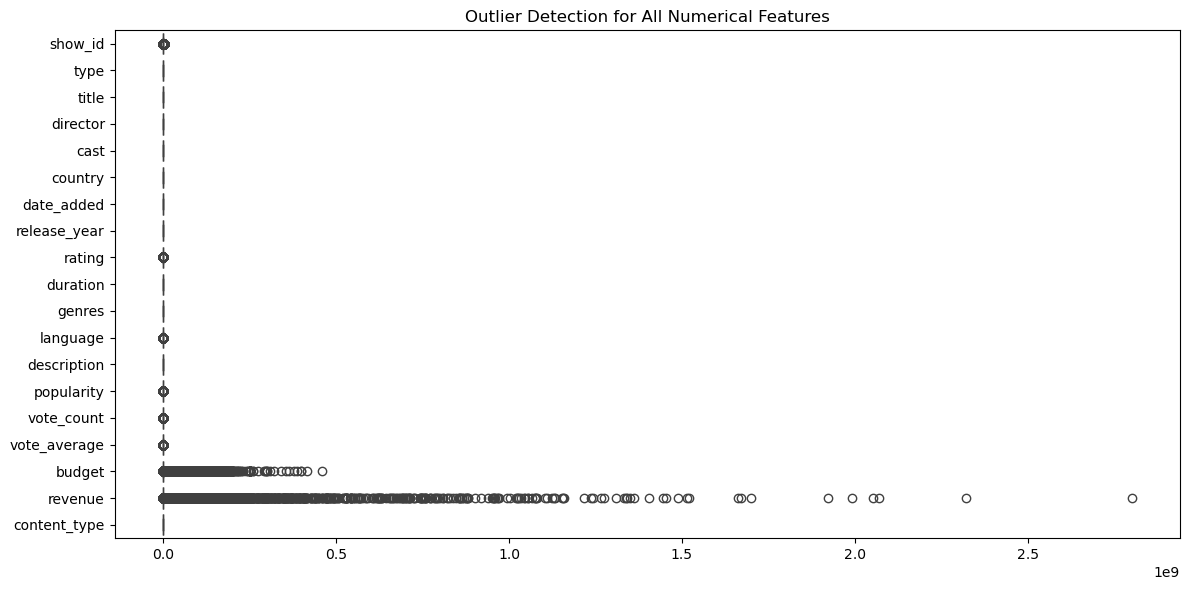

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_cols],
    orient='h'
)

plt.title("Outlier Detection for All Numerical Features")
plt.tight_layout()

plt.show()

### Outlier Detection
* Revenue and Budget contain significant outliers, indicating a few titles generated exceptionally high earnings and had very large production budgets.
* Most other numerical features show relatively fewer extreme values.
* The presence of outliers suggests a highly skewed distribution, especially for financial variables.
* These outliers may represent blockbuster productions and should be considered during preprocessing and clustering analysis.

In [11]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    percentage = (len(outliers)/len(df))*100

    print(
        f"{col}: {len(outliers)} outliers ({percentage:.2f}%)"
    )

show_id: 2413 outliers (7.54%)
type: 0 outliers (0.00%)
title: 0 outliers (0.00%)
director: 0 outliers (0.00%)
cast: 0 outliers (0.00%)
country: 0 outliers (0.00%)
date_added: 0 outliers (0.00%)
release_year: 0 outliers (0.00%)
rating: 4931 outliers (15.41%)
duration: 0 outliers (0.00%)
genres: 0 outliers (0.00%)
language: 2868 outliers (8.96%)
description: 0 outliers (0.00%)
popularity: 2833 outliers (8.85%)
vote_count: 4378 outliers (13.68%)
vote_average: 4931 outliers (15.41%)
budget: 4847 outliers (15.15%)
revenue: 5645 outliers (17.64%)
content_type: 0 outliers (0.00%)


In [12]:
# Feature Scaling

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


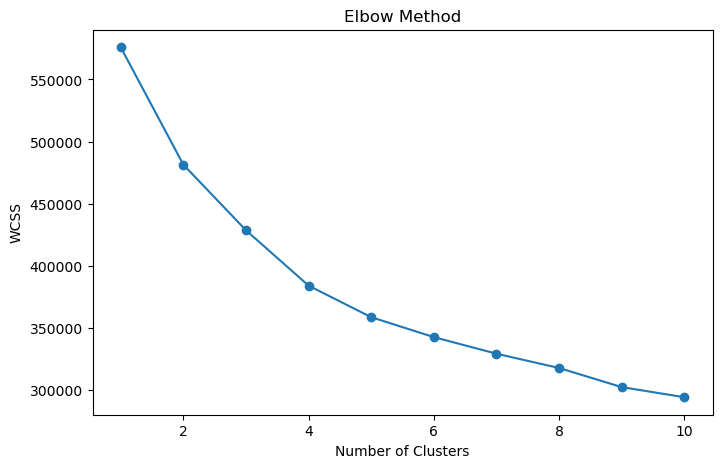

In [13]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Elbow Method
* WCSS decreases as the number of clusters increases, indicating improved clustering.
* A noticeable bend (elbow) appears around K = 4, suggesting 4 clusters as the optimal choice.
* After K = 4, the reduction in WCSS becomes gradual, meaning additional clusters provide limited improvement.
* This indicates that the dataset naturally groups into four meaningful clusters.

In [14]:
# K-Means Clustering
# (Assume Optimal K = 4)

kmeans = KMeans(
    n_clusters=4,

    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

# Add Cluster Column
df["Cluster"] = clusters
print("\nCluster Counts:")
print(df["Cluster"].value_counts())


Cluster Counts:
Cluster
1    15391
0    11795
3     4313
2      501
Name: count, dtype: int64


In [15]:
# Evaluation Metrics

silhouette = silhouette_score(scaled_data, clusters)
db_index = davies_bouldin_score(scaled_data, clusters)

print("\nSilhouette Score:", round(silhouette,3))
print("Davies-Bouldin Index:", round(db_index,3))


Silhouette Score: 0.2
Davies-Bouldin Index: 1.557


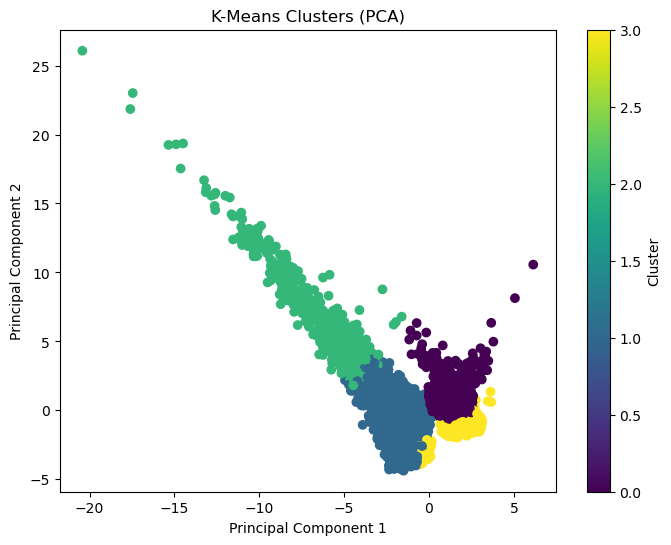

In [16]:
# PCA for 2D Visualization
   
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA)")
plt.colorbar(label="Cluster")
plt.show()

### K-Means PCA Cluster Plot
* Four distinct clusters are formed, indicating that K-Means successfully identified natural groupings in the dataset.
* Most data points are densely packed, showing similarities among many movies and TV shows.
* Cluster separation is reasonably clear, suggesting effective clustering performance.
* A few outliers are present, representing unique or highly different content.
* PCA visualization confirms that the dataset contains meaningful hidden patterns suitable for segmentation and   recommendation systems.

In [23]:
# Cluster Characteristics

cluster_summary = df.groupby("Cluster").mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
               show_id      type         title      director          cast  \
Cluster                                                                      
0        114368.301229  0.999661  15354.282408  10432.066469  16105.425350   
1        531276.630368  0.000000  15000.144435   6370.300240  14644.414658   
2        286072.628743  0.007984  15672.413174   6060.916168  14343.465070   
3        181413.970090  0.974959  16523.021795  10346.687920  16611.712961   

             country   date_added  release_year    rating  duration  \
Cluster                                                               
0        1217.621365  5447.212802   2017.575583  7.241155       0.0   
1        1238.297447  3851.056916   2017.507115  5.967854       0.0   
2        1449.327345  3840.091816   2016.293413  6.894733       0.0   
3        1156.618827  5370.494551   2017.408069  0.292295       0.0   

              genres   language   description  popularity   vote_count  \
Cluster     

In [18]:
# Save Dataset with Cluster Labels

df.to_csv("clustered_dataset.csv", index=False)

print("\nClustered dataset saved successfully!")


Clustered dataset saved successfully!


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

preprocessor = StandardScaler()

netflix_pipeline = Pipeline([
    ('scaler', preprocessor),
    ('model', KMeans(n_clusters=4, random_state=42, n_init=10))
])

netflix_pipeline.fit(df)

joblib.dump(netflix_pipeline, 'netflix_clustering_pipeline.pkl')

print("Model exported successfully!")

Model exported successfully!


### Conclusion
This project successfully used K-Means clustering to identify hidden patterns and group similar Netflix movies and TV shows based on their characteristics. The discovered clusters provide valuable insights into content performance and demonstrate how unsupervised learning can support recommendation systems and data-driven decision-making.